# **Project Name**    - IT Customer Churn Prediction



##### **Project Type**    - EDA/Classification
##### **Contribution**    - Individual
##### **Team Member -** Varun Singh


# **Project Summary -**

# Project Summary

Customer churn is one of the most significant challenges faced by organizations in the IT and telecommunications industry. Acquiring a new customer is generally more expensive than retaining an existing one, making customer retention a key factor in maintaining profitability and long-term business growth. This project focuses on developing a machine learning-based classification model that predicts whether a customer is likely to discontinue a company's services. By identifying customers who are at risk of leaving, businesses can implement proactive retention strategies, improve customer satisfaction, and reduce revenue loss.

The project utilizes the IBM Telco Customer Churn dataset, which contains customer demographic information, account details, subscribed services, billing information, and churn status. The dataset includes features such as gender, senior citizen status, tenure, contract type, internet service, payment method, monthly charges, total charges, and various value-added services. The target variable, **Churn**, indicates whether a customer has left the company. Before building predictive models, extensive data preprocessing was performed to ensure data quality. This included handling missing values, converting data types, encoding categorical variables, removing duplicate records, and preparing the dataset for machine learning algorithms.

Exploratory Data Analysis (EDA) was conducted to gain insights into customer behavior and identify the factors influencing churn. Multiple univariate, bivariate, and multivariate visualizations were created to analyze the distribution of customer characteristics and their relationship with churn. These visualizations highlighted patterns such as higher churn rates among customers with month-to-month contracts, higher monthly charges, shorter tenure, and limited additional service subscriptions. The insights obtained from EDA provided a strong foundation for feature selection and model development.

Several supervised machine learning classification algorithms were implemented to predict customer churn, including Logistic Regression, Decision Tree, and Random Forest. The dataset was divided into training and testing sets using a stratified train-test split to maintain class balance. Each model was trained and evaluated using standard classification metrics such as Accuracy, Precision, Recall, F1-Score, Confusion Matrix, ROC Curve, and Area Under the Curve (AUC). Hyperparameter tuning was also performed using GridSearchCV to improve model performance and reduce the risk of overfitting. Feature importance analysis was carried out to identify the most influential factors contributing to customer churn.

The comparative analysis of multiple classification models enabled the selection of the most effective model based on predictive performance and generalization capability. The results demonstrated that machine learning can accurately identify customers who are likely to churn, allowing organizations to take preventive actions before customer attrition occurs. These predictions can support personalized marketing campaigns, improved customer service, targeted promotional offers, and strategic business decision-making.

Overall, this project demonstrates the practical application of machine learning techniques in solving real-world business problems. By combining data preprocessing, exploratory data analysis, predictive modeling, and performance evaluation, the proposed solution provides valuable insights into customer behavior and helps organizations develop effective customer retention strategies. The project highlights how data-driven decision-making can improve operational efficiency, enhance customer loyalty, and contribute to sustainable business growth in the competitive IT and telecommunications industry.


# **GitHub Link -**

https://github.com/Varun270405/EDA-and-Classification-model-Project/tree/main.

# **Problem Statement**



Customer churn is a major challenge for IT and telecommunications companies, as losing existing customers leads to reduced revenue and increased customer acquisition costs. Predicting which customers are likely to leave is essential for improving customer retention. This project aims to develop a machine learning classification model that analyzes customer demographics, service usage, contract details, and billing information to predict customer churn accurately. The insights gained from the model can help businesses implement targeted retention strategies, enhance customer satisfaction, and support data-driven decision-making.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [100]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


### Dataset Loading

In [101]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
# Load Dataset
path = '/content/drive/MyDrive/Colab Notebooks/IT_customer_churn.csv'
df = pd.read_csv(path)

### Dataset First View

In [103]:
# Dataset First Look
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Dataset Rows & Columns count

In [104]:
# Dataset Rows & Columns count
df.shape

(7043, 20)

### Dataset Information

In [105]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


#### Duplicate Values

In [106]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(22)

#### Missing Values/Null Values

In [107]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


### What did you know about your dataset?



* The dataset contains **7,043 customer records** and **20 columns**.
* The target variable is **Churn**, making it a **binary classification** problem where the objective is to predict whether a customer will leave the company.
* It consists of both **categorical** and **numerical** features, including customer demographics, subscribed services, contract details, and billing information.
* The dataset contains **22 duplicate records**, which should be removed before model building to improve data quality.
* No **null values** are detected using `isnull().sum()`, but the **TotalCharges** column contains blank entries stored as spaces, which need to be converted to `NaN` and handled during preprocessing.
* The **TotalCharges** column is currently of **object** data type and should be converted to a numeric data type.
* Overall, the dataset is well-structured and requires only minor preprocessing, such as removing duplicates, handling blank values, and encoding categorical variables, before performing exploratory data analysis and building classification models.


## ***2. Understanding Your Variables***

In [108]:
# Dataset Columns
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [109]:
# Dataset Describe
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Variables Description



| Variable             | Description                                                                |
| -------------------- | -------------------------------------------------------------------------- |
| **gender**           | Customer's gender (Male/Female).                                           |
| **SeniorCitizen**    | Indicates whether the customer is a senior citizen (1 = Yes, 0 = No).      |
| **Partner**          | Whether the customer has a partner (Yes/No).                               |
| **Dependents**       | Whether the customer has dependents (Yes/No).                              |
| **tenure**           | Number of months the customer has stayed with the company.                 |
| **PhoneService**     | Whether the customer has a phone service subscription.                     |
| **MultipleLines**    | Whether the customer has multiple phone lines.                             |
| **InternetService**  | Type of internet service subscribed (DSL, Fiber Optic, or No).             |
| **OnlineSecurity**   | Whether the customer has an online security service.                       |
| **OnlineBackup**     | Whether the customer has an online backup service.                         |
| **DeviceProtection** | Whether the customer has device protection.                                |
| **TechSupport**      | Whether the customer has technical support.                                |
| **StreamingTV**      | Whether the customer subscribes to streaming TV services.                  |
| **StreamingMovies**  | Whether the customer subscribes to streaming movie services.               |
| **Contract**         | Type of customer contract (Month-to-month, One year, Two year).            |
| **PaperlessBilling** | Whether the customer uses paperless billing.                               |
| **PaymentMethod**    | Customer's payment method.                                                 |
| **MonthlyCharges**   | Monthly amount charged to the customer.                                    |
| **TotalCharges**     | Total amount charged to the customer during their tenure.                  |
| **Churn**            | Target variable indicating whether the customer left the company (Yes/No). |


### Check Unique Values for each variable.

In [110]:
# Check Unique Values for each variable.
df.nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3


## 3. ***Data Wrangling***

### Data Wrangling Code

In [111]:
# Write your code to make your dataset analysis ready.
print("Duplicate values before:", df.duplicated().sum())

# Remove duplicate values
df.drop_duplicates(inplace=True)

print("Duplicate values after:", df.duplicated().sum())


Duplicate values before: 22
Duplicate values after: 0


In [112]:
# Replace blank spaces with NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Convert TotalCharges into numeric datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])


In [113]:
print(df.isnull().sum())


# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


# Verify missing values
print(df.isnull().sum())


gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


/tmp/ipykernel_1506/1082419458.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

In [115]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### What all manipulations have you done and insights you found?


* Identified and removed **22 duplicate records** to improve data quality.
* Replaced blank values in the **TotalCharges** column with `NaN`.
* Converted the **TotalCharges** column from **object** to **numeric** data type.
* Filled the missing values in **TotalCharges** using the **median**, ensuring no data loss.
* Verified that the dataset contains no missing values after preprocessing.
* Confirmed that all variables have appropriate data types for further analysis.
* Prepared a clean dataset for **Exploratory Data Analysis (EDA)** and visualization.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Distribution of Customer Chrun

In [116]:
df['Churn'].value_counts()

,count
Churn,
No,5164
Yes,1857


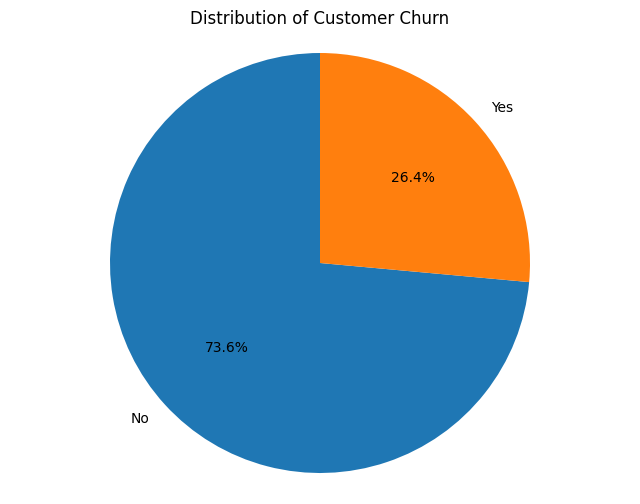

In [117]:
# Chart - 1 visualization code
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Customer Churn')
plt.axis('equal')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is used to visualize the proportion of customers who stayed with the company versus those who churned. It provides a clear representation of the target variable and helps understand the overall distribution of customer retention and attrition.

##### 2. What is/are the insight(s) found from the chart?

* The majority of customers belong to the "No Churn" category, indicating that most customers continue using the company's services.
* Approximately 26–27% of customers have churned, while around 73–74% have remained with the company.
* The dataset is moderately imbalanced, with retained customers significantly outnumbering churned customers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.



**Business Impact**

* A high customer retention rate indicates stable business performance.
* However, losing nearly one-fourth of customers can result in considerable revenue loss and increased customer acquisition costs.
* Understanding the churn proportion helps businesses focus on customer retention strategies, loyalty programs, and personalized services to reduce future churn.

**Negative Growth**

* The percentage of churned customers is substantial and should not be overlooked.
* If the churn rate continues to increase, the company may experience declining revenue, reduced customer lifetime value, and higher marketing costs for acquiring new customers.
* Identifying the reasons behind customer churn is essential for improving long-term business growth and competitiveness.


#### Chart - 2 : Distribution of Customer Tenure

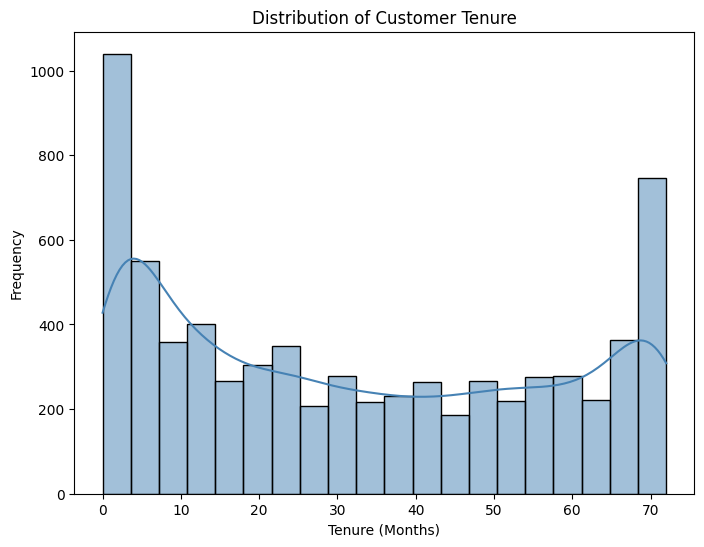

In [118]:
# Chart - 2 visualization code
plt.figure(figsize=(8, 6))
sns.histplot(df['tenure'], bins=20, kde=True, color = 'steelblue')
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a Kernel Density Estimation (KDE) curve is used to examine the distribution of customer tenure. It helps identify how long customers typically remain with the company and whether customer retention is concentrated within specific time periods.

##### 2. What is/are the insight(s) found from the chart?

* The distribution shows that a large number of customers have either recently joined or have remained with the company for a long duration.
* The tenure variable is not uniformly distributed, indicating varying levels of customer loyalty.
* A noticeable concentration of customers with lower tenure suggests that many customers discontinue services during the initial months.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


**Business Impact**

* Customers with shorter tenure may require additional engagement through onboarding support, promotional offers, or personalized communication to improve retention.
* Long-tenure customers represent loyal customers who contribute significantly to recurring revenue and should be rewarded through loyalty programs and premium services.

**Negative Growth**

* A higher concentration of customers with low tenure may indicate difficulties in retaining newly acquired customers.
* Failure to improve early customer experience could increase churn rates, resulting in higher customer acquisition costs and reduced long-term profitability.


#### Chart - 3 : Distribution of Contract Types

In [119]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3853
Two year,1695
One year,1473


/tmp/ipykernel_1506/761437171.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Contract', palette='pastel')


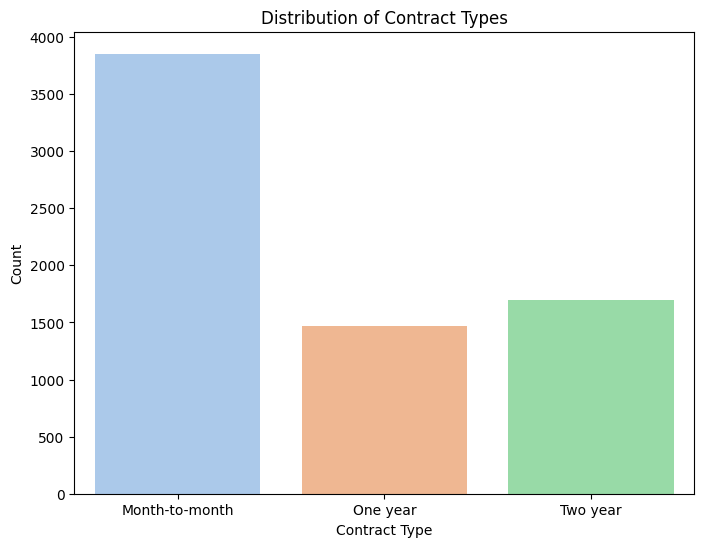

In [120]:
# Chart - 3 visualization code
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contract', palette='pastel')
plt.title('Distribution of Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()


##### 1. Why did you pick the specific chart?

A count plot is used to display the frequency of customers across different contract types. It is one of the most effective visualizations for categorical variables, allowing easy comparison of the number of customers in each contract category.

##### 2. What is/are the insight(s) found from the chart?


* The **Month-to-month** contract has the highest number of customers.
* **One-year** and **Two-year** contracts have significantly fewer customers compared to month-to-month contracts.
* This indicates that most customers prefer short-term contracts, possibly due to greater flexibility and fewer long-term commitments.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


### Business Impact

The high number of customers on month-to-month contracts indicates that many customers are not committed to long-term service plans. Since these customers can easily discontinue the service, the company should encourage them to switch to one-year or two-year contracts by offering discounts, loyalty rewards, or bundled services. Increasing long-term subscriptions can improve customer retention, stabilize revenue, and reduce customer acquisition costs.

### Negative Growth

A larger customer base on month-to-month contracts increases the risk of customer churn because customers can leave the company at any time without contractual obligations. If the company fails to convert these customers into long-term contracts, it may experience higher churn rates, unstable revenue, and increased costs associated with acquiring new customers.


#### Chart - 4 : Distribution of Monthly Charges

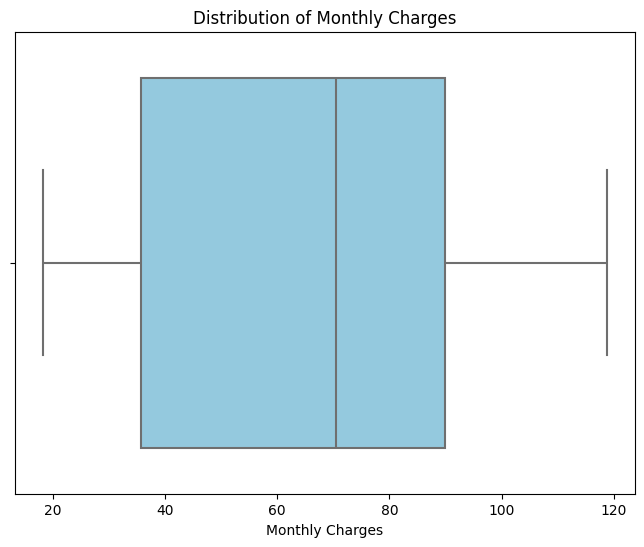

In [121]:
# Chart - 4 visualization code
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='MonthlyCharges', color='skyblue', linewidth=1.5, fliersize=4)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is used to summarize the distribution of the Monthly Charges variable. It provides information about the median, spread of the data, interquartile range (IQR), and potential outliers. This chart is useful for identifying whether customers have unusually high or low monthly charges.

##### 2. What is/are the insight(s) found from the chart?



* The monthly charges are spread across a wide range, indicating that customers subscribe to different service plans.
* The median monthly charge lies near the center of the distribution, while the box represents the middle 50% of customers.
* A few outliers may be present, representing customers with exceptionally high monthly charges due to premium plans or additional services.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


### Business Impact

Understanding the distribution of monthly charges helps the company evaluate its pricing strategy and customer segmentation. Customers paying higher monthly charges contribute more revenue, but they may also have higher service expectations. Analyzing pricing distribution enables the business to design competitive plans, optimize pricing, and improve customer satisfaction.

### Negative Growth

If a significant number of customers are paying very high monthly charges without receiving sufficient value, they may be more likely to discontinue the service. High-priced plans without corresponding customer satisfaction can increase churn and negatively affect long-term revenue growth.


#### Chart - 5 : Distribution of Total Charges (Violin Plot)

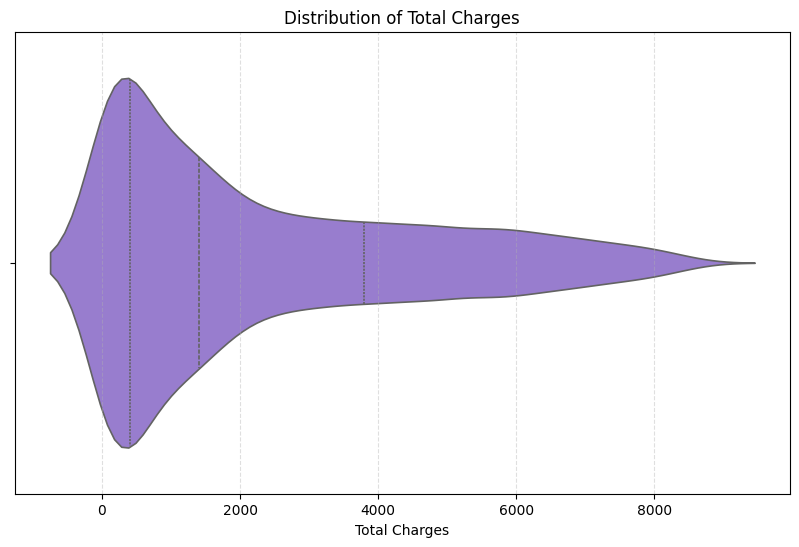

In [122]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='TotalCharges', color='mediumpurple',inner= 'quartile', linewidth=1.2)
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

##### 1. Why did you pick the specific chart?

A violin plot is used to visualize the distribution of Total Charges by combining the features of a box plot and a density plot. It provides information about the spread, median, quartiles, and concentration of customer payments, making it useful for understanding how total charges vary across the customer base.

##### 2. What is/are the insight(s) found from the chart?


* The distribution of total charges is not uniform, with customers spread across a wide range of payment amounts.
* Most customers are concentrated in the lower to middle range of total charges, while fewer customers have very high total charges.
* The wider sections of the violin indicate where customer payments are more concentrated, whereas the narrower sections represent fewer observations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.



### Business Impact

Analyzing total charges helps the company understand customer spending patterns and identify high-value customers. Customers with higher total charges generally contribute more to overall revenue and may benefit from loyalty programs, personalized offers, and premium support to strengthen long-term relationships.

### Negative Growth

A small proportion of customers with high total charges may indicate that premium services are subscribed to by only a limited customer segment. If these high-value customers churn, the company could experience a significant loss in revenue. Therefore, retaining high-paying customers is essential for maintaining stable business growth.


#### Chart - 6 : Distribution of Payment Methods (Horizontal Bar Plot)

In [123]:
payment_counts = df['PaymentMethod'].value_counts()

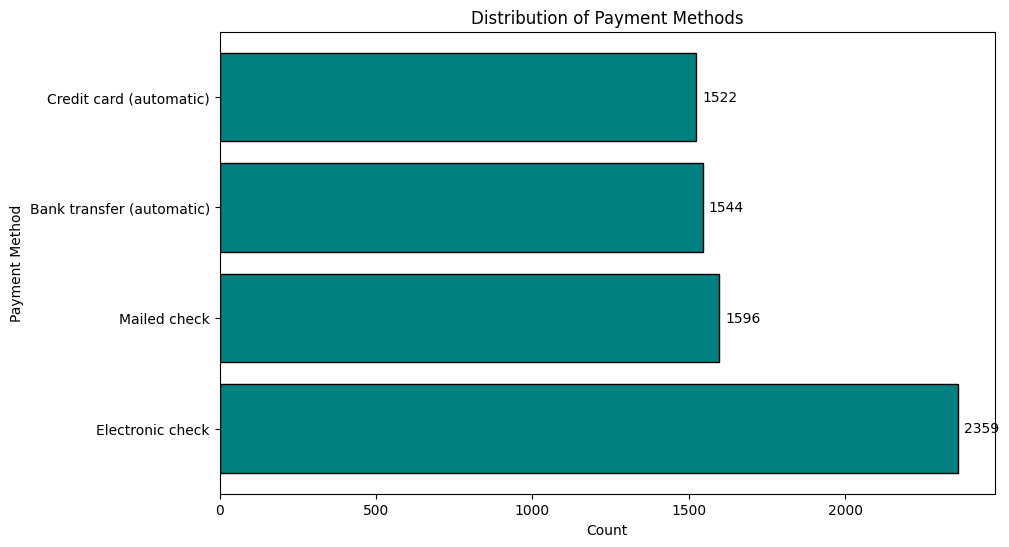

In [124]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 6))
plt.barh(payment_counts.index, payment_counts.values, color='teal', edgecolor='black')

# Add value labels
for index, value in enumerate(payment_counts.values):
    plt.text(value + 20, index, str(value), va='center', fontsize=10)

plt.xlabel('Count')
plt.title('Distribution of Payment Methods')
plt.xlabel('Count')
plt.ylabel('Payment Method')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar plot is used to compare the number of customers using different payment methods. It is particularly effective for categorical variables with long category names, as it improves readability and makes comparisons between categories easier.

##### 2. What is/are the insight(s) found from the chart?



* Customers use multiple payment methods, with some methods being significantly more popular than others.
* Electronic check is commonly used by a large proportion of customers, while bank transfers, credit cards, and mailed checks have comparatively different customer counts.
* The variation in payment preferences indicates that customers value flexibility in payment options.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


### Business Impact

Understanding customer payment preferences helps the company optimize payment services and improve customer convenience. Promoting secure and automated payment methods, such as bank transfers and credit card payments, can reduce payment delays, improve operational efficiency, and enhance the overall customer experience.

### Negative Growth

A high dependence on manual or less reliable payment methods may increase payment failures, delayed collections, or service interruptions. If customers experience inconvenience during the payment process, it may reduce customer satisfaction and contribute to higher churn rates.


#### Chart - 7 : Distribution of Internet Service

In [125]:
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3090
DSL,2419
No,1512


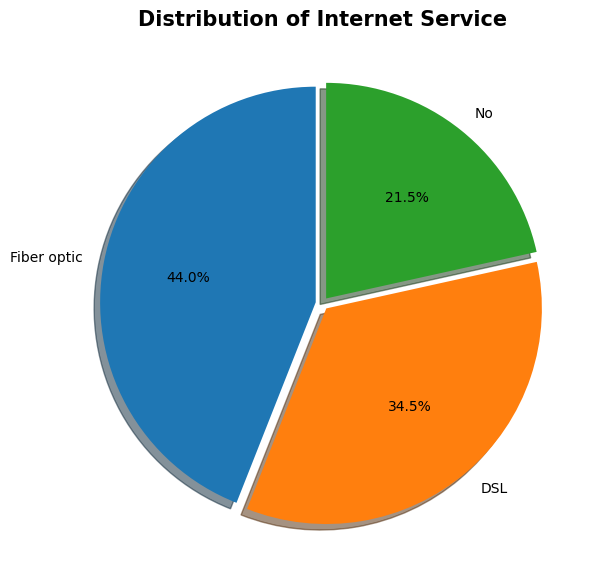

In [126]:
plt.figure(figsize=(7,7))

internet_counts = df['InternetService'].value_counts()

plt.pie(
    internet_counts,
    labels=internet_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.03]*len(internet_counts),
    shadow=True
)

plt.title('Distribution of Internet Service', fontsize=15, fontweight='bold')

plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is used to illustrate the proportion of customers using different internet service types. It effectively represents how the total customer base is distributed among the available service categories, making percentage comparisons simple and intuitive.

##### 2. What is/are the insight(s) found from the chart?



* Fiber optic and DSL services account for the majority of customers, while a smaller proportion of customers do not subscribe to any internet service.
* The distribution indicates that internet connectivity is a core service for most customers.
* The varying proportions reflect customer preferences for different internet technologies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.



### Business Impact

Understanding the distribution of internet service types helps the company identify its most widely used services and allocate resources accordingly. If fiber optic services have a large customer base, maintaining service quality and expanding network infrastructure can improve customer satisfaction. Marketing efforts can also target customers without internet services to encourage additional service adoption.

### Negative Growth

If customers using a particular internet service experience poor performance or frequent service issues, the company may face increased churn within that segment. Additionally, a low adoption rate of certain services may indicate limited market demand or ineffective promotional strategies, reducing opportunities for revenue growth.


#### Chart - 8 : Churn vs Contract Type

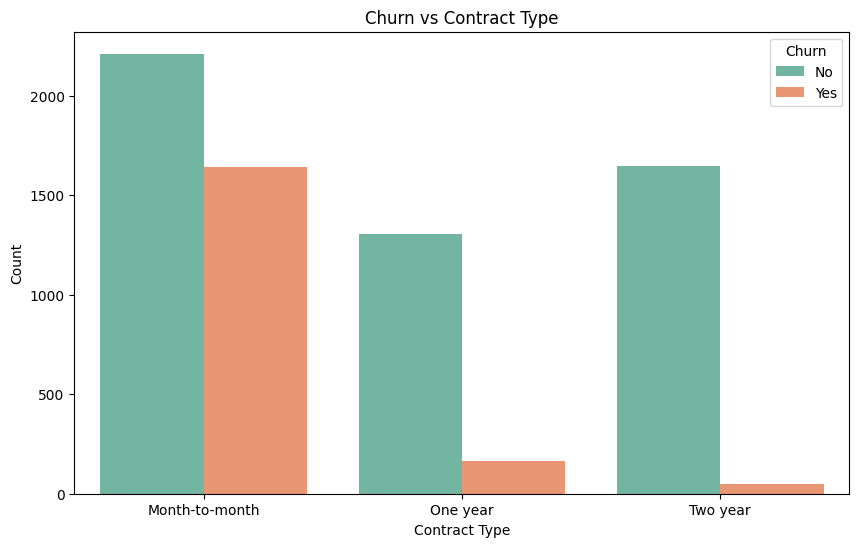

In [127]:
# Chart - 8 visualization code
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn vs Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn', loc='upper right')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart (count plot with hue) is used to compare the number of customers who churned and those who stayed across different contract types. It clearly highlights the relationship between contract duration and customer churn, making it easier to identify which contract type is associated with higher customer retention.

##### 2. What is/are the insight(s) found from the chart?



* Customers with **month-to-month contracts** show the highest number of churn cases.
* Customers enrolled in **one-year** and **two-year contracts** have significantly lower churn compared to month-to-month customers.
* Longer contract durations appear to improve customer retention, suggesting that customers with long-term commitments are less likely to leave the company.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


### Business Impact

The analysis indicates that contract duration plays a crucial role in customer retention. The company can reduce churn by encouraging month-to-month customers to upgrade to one-year or two-year contracts through discounts, loyalty benefits, or bundled service plans. Increasing long-term subscriptions can improve revenue stability and customer lifetime value.

### Negative Growth

A large number of churn cases among month-to-month customers indicates a high risk of customer loss within this segment. If the company fails to retain these customers or convert them into long-term contracts, it may experience increased churn rates, unstable recurring revenue, and higher customer acquisition costs.


#### Chart - 9 : Churn by Internet Service

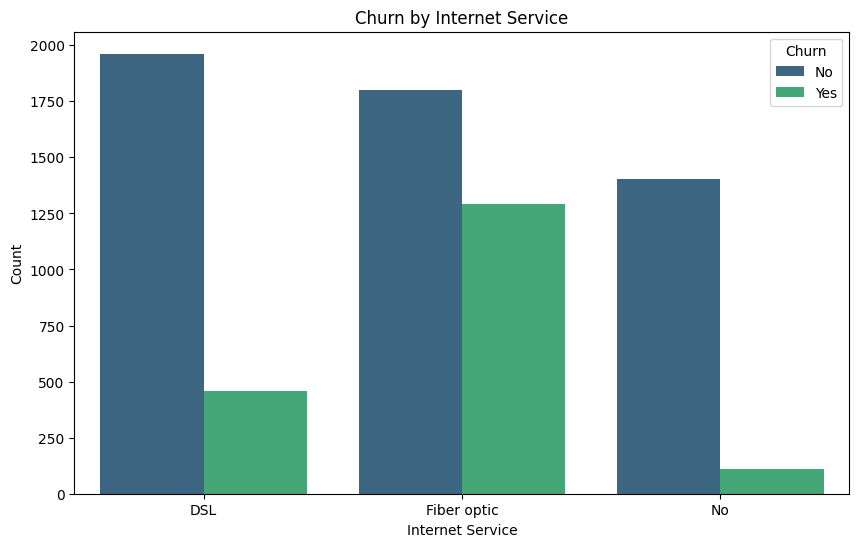

In [128]:
# Chart - 9 visualization code
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='viridis')
plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.legend(title='Churn', loc='upper right')
plt.show()

##### 1. Why did you pick the specific chart?


A grouped bar chart (count plot with **hue**) is used to compare the number of customers who churned and those who remained across different internet service types. This visualization makes it easy to identify whether a particular internet service is associated with higher customer churn.




##### 2. What is/are the insight(s) found from the chart?


* Customers using **Fiber optic** internet service exhibit a higher number of churn cases compared to customers using DSL or no internet service.
* Customers with **DSL** connections tend to have relatively better retention.
* Customers without an internet service show the lowest churn, indicating greater stability within this customer segment.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


### Business Impact

The analysis suggests that the type of internet service influences customer retention. The company should investigate why Fiber optic customers leave more frequently by evaluating factors such as pricing, service quality, network reliability, and customer support. Improving these areas can enhance customer satisfaction and reduce churn among high-value internet users.

### Negative Growth

A consistently high churn rate among Fiber optic customers can result in significant revenue loss because these customers often subscribe to premium services. If the company does not address the underlying causes of dissatisfaction, customer attrition may continue to increase, negatively affecting profitability and long-term business growth.


#### Chart - 10 : Churn by Payment Method

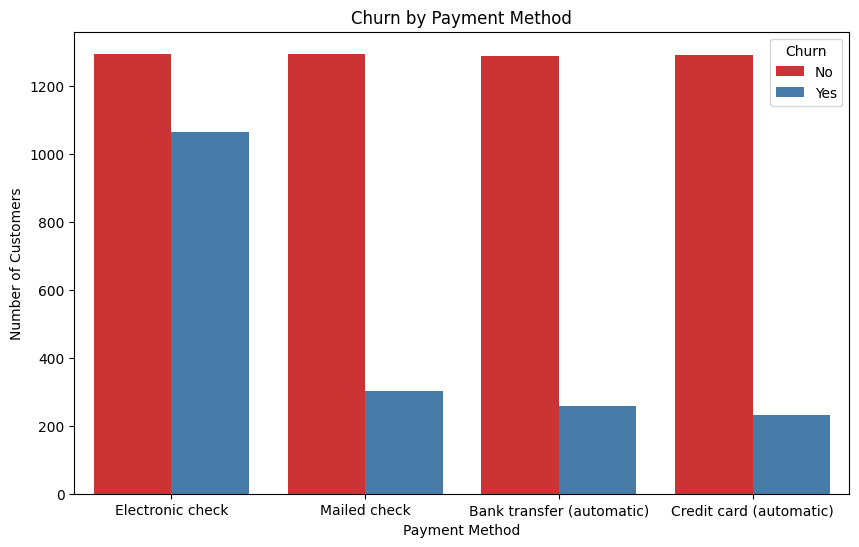

In [129]:
# Chart - 10 visualization code
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='Set1')
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', loc='upper right')
plt.show()

##### 1. Why did you pick the specific chart?



A grouped bar chart (count plot with **hue**) is used to compare customer churn across different payment methods. This visualization helps identify whether certain payment methods are associated with higher customer retention or higher customer attrition by displaying churned and retained customers side by side.



##### 2. What is/are the insight(s) found from the chart?



* Customers using **Electronic check** show the highest number of churn cases among all payment methods.
* Customers paying through **Bank transfer (automatic)** and **Credit card (automatic)** generally exhibit lower churn, indicating better customer retention.
* Automatic payment methods appear to be associated with more stable customer relationships compared to manual payment methods.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


### Business Impact

The company can improve customer retention by encouraging customers to switch from manual payment methods to automatic payment options. Providing incentives such as cashback, discounts, or simplified auto-payment enrollment can improve payment consistency, reduce missed payments, and strengthen long-term customer relationships.

### Negative Growth

A high churn rate among customers using Electronic check may indicate payment inconvenience or lower customer engagement. If this trend continues, the company could experience increasing customer attrition and reduced recurring revenue. Addressing payment-related issues and promoting automated payment methods can help minimize future churn.


#### Chart - 11 : Churn by Tech Support

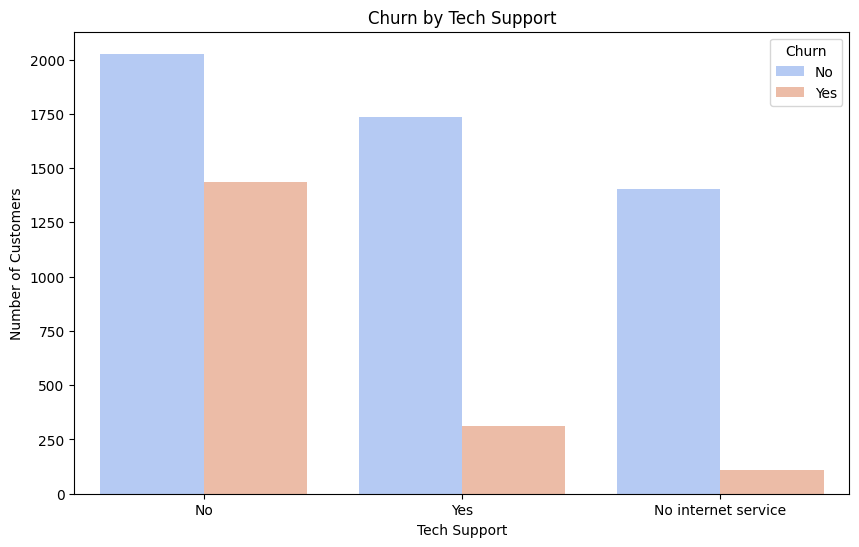

In [130]:
# Chart - 11 visualization code
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='TechSupport', hue='Churn', palette='coolwarm')
plt.title('Churn by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', loc='upper right')
plt.show()

##### 1. Why did you pick the specific chart?


A grouped bar chart (count plot with **hue**) is used to compare customer churn across different Tech Support categories. This visualization helps determine whether access to technical support influences customer retention by displaying churned and retained customers side by side.



##### 2. What is/are the insight(s) found from the chart?



* Customers **without Tech Support** have a significantly higher number of churn cases compared to those who receive technical support.
* Customers who subscribe to **Tech Support** show better retention, indicating that assistance and timely issue resolution improve customer satisfaction.
* The results suggest that technical support is an important factor influencing customer loyalty and long-term service usage.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


### Business Impact

Providing reliable technical support can substantially improve customer retention. The company should encourage customers without Tech Support to subscribe through promotional offers, bundled service packages, or free trial periods. Faster issue resolution and proactive customer assistance can increase satisfaction, strengthen customer relationships, and improve customer lifetime value.

### Negative Growth

A high churn rate among customers without Tech Support indicates that unresolved technical issues or inadequate customer assistance may lead customers to switch to competitors. If the company does not improve technical support accessibility and service quality, it may continue to experience higher churn and reduced long-term revenue.


#### Chart - 12 : Monthly Charges by Churn

/tmp/ipykernel_1506/3205705435.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set3')


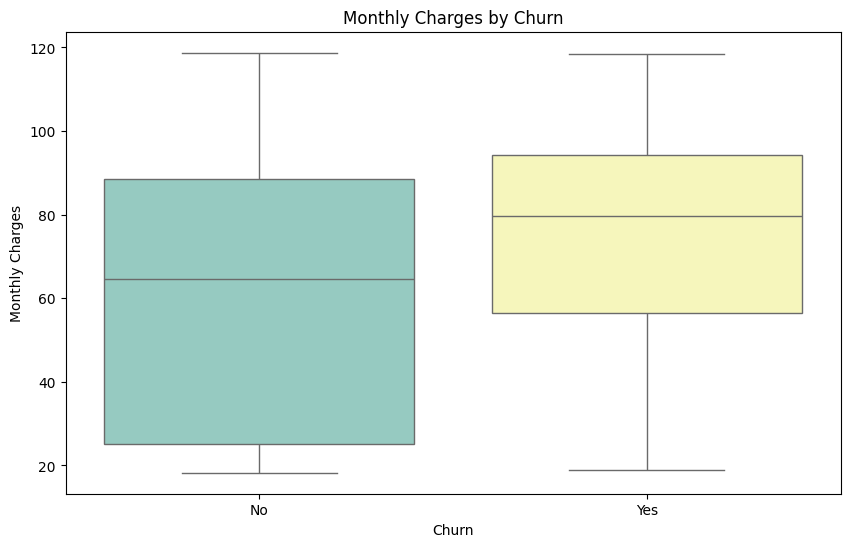

In [131]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set3')
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

##### 1. Why did you pick the specific chart?


A box plot is used to compare the distribution of **Monthly Charges** between customers who churned and those who remained. It summarizes the median, quartiles, spread, and potential outliers, making it an effective visualization for identifying differences in monthly billing across churn categories.



##### 2. What is/are the insight(s) found from the chart?



* Customers who **churned** generally have higher monthly charges than customers who remained with the company.
* The churned customer group exhibits a wider spread of monthly charges, indicating greater variability in their billing amounts.
* Higher monthly charges appear to be associated with an increased likelihood of customer churn.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.



### Business Impact

The company should carefully evaluate pricing strategies and service plans for customers with higher monthly charges. Introducing personalized discounts, loyalty rewards, bundled service packages, or value-added benefits for high-paying customers can improve customer satisfaction and reduce churn. Monitoring customers with consistently high monthly bills can also help identify individuals who may require proactive retention efforts.

### Negative Growth

If customers continue to perceive that they are paying high monthly charges without receiving sufficient value, dissatisfaction and churn are likely to increase. A sustained loss of high-paying customers can significantly reduce recurring revenue, increase customer acquisition costs, and negatively affect the company's long-term profitability.


#### Chart - 13 : Tenure vs Monthly Charges by Churn

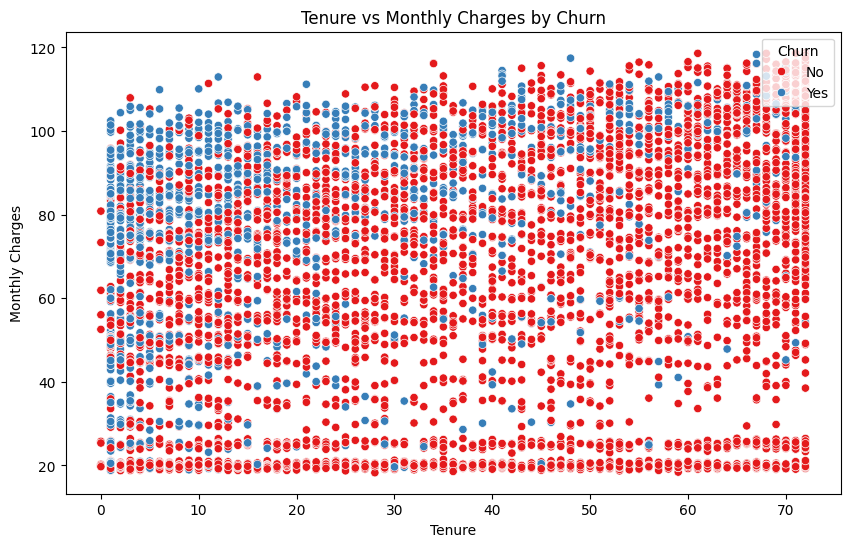

In [132]:
# Chart - 13 visualization code
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', palette='Set1')
plt.title('Tenure vs Monthly Charges by Churn')
plt.xlabel('Tenure')
plt.ylabel('Monthly Charges')
plt.legend(title='Churn', loc='upper right')
plt.show()


##### 1. Why did you pick the specific chart?



A scatter plot is used to examine the relationship between **Tenure** and **Monthly Charges**, while distinguishing customers based on their churn status using different colors. This multivariate visualization helps identify customer segments with similar billing patterns and subscription durations, making it easier to detect trends associated with customer churn.



##### 2. What is/are the insight(s) found from the chart?


* Customers who **churned** are more concentrated in the region of **shorter tenure** and **higher monthly charges**.
* Customers with **longer tenure** generally exhibit lower churn, regardless of their monthly charges, indicating stronger customer loyalty.
* The scatter plot reveals that tenure has a significant influence on customer retention, while high monthly charges further increase the likelihood of churn among newer customers.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


### Business Impact

The company should focus its retention strategies on customers who have recently joined and are paying relatively high monthly charges. Personalized onboarding, promotional discounts, loyalty incentives, and proactive customer engagement during the initial months can improve satisfaction and reduce early customer attrition. Long-term customers should continue receiving loyalty benefits to maintain strong retention.

### Negative Growth

If newly acquired customers with high monthly charges continue to leave early, the company will face increasing acquisition costs and reduced customer lifetime value. Persistently losing these customers can weaken recurring revenue growth and negatively impact overall business profitability.


#### Chart - 14 - Correlation Heatmap

In [133]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

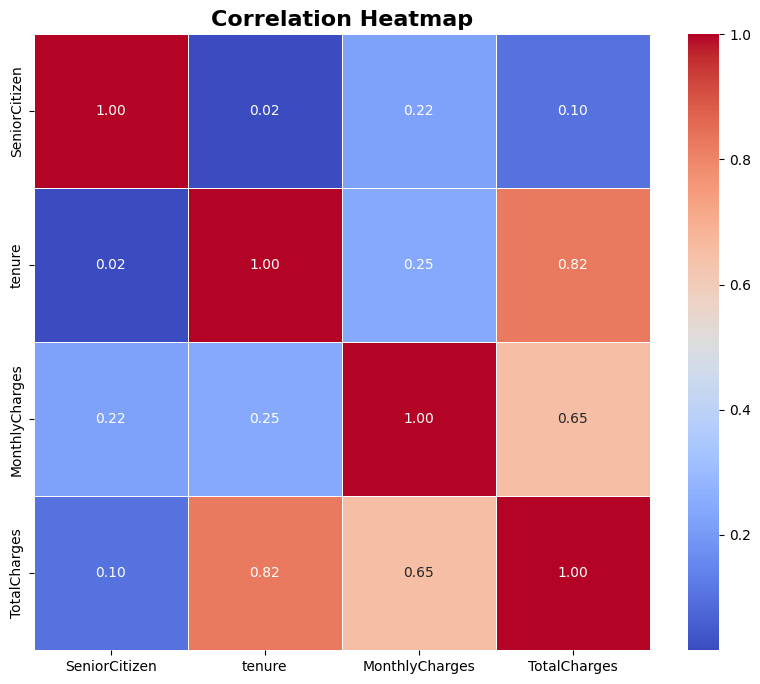

In [134]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')

plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is used to visualize the strength and direction of relationships between numerical variables in the dataset. It provides a comprehensive overview of how different features are related, making it easier to identify strong positive or negative correlations and detect potential multicollinearity before building machine learning models.

##### 2. What is/are the insight(s) found from the chart?

* Most numerical features exhibit weak to moderate correlations, indicating that each variable contributes unique information.
Features such as Monthly Charges,
* Total Charges, and Tenure generally show stronger relationships compared to other variables.
* The heatmap helps identify variables that may have a greater influence on customer churn and highlights any redundant features that could affect model performance.

#### Chart - 15 - Pair Plot

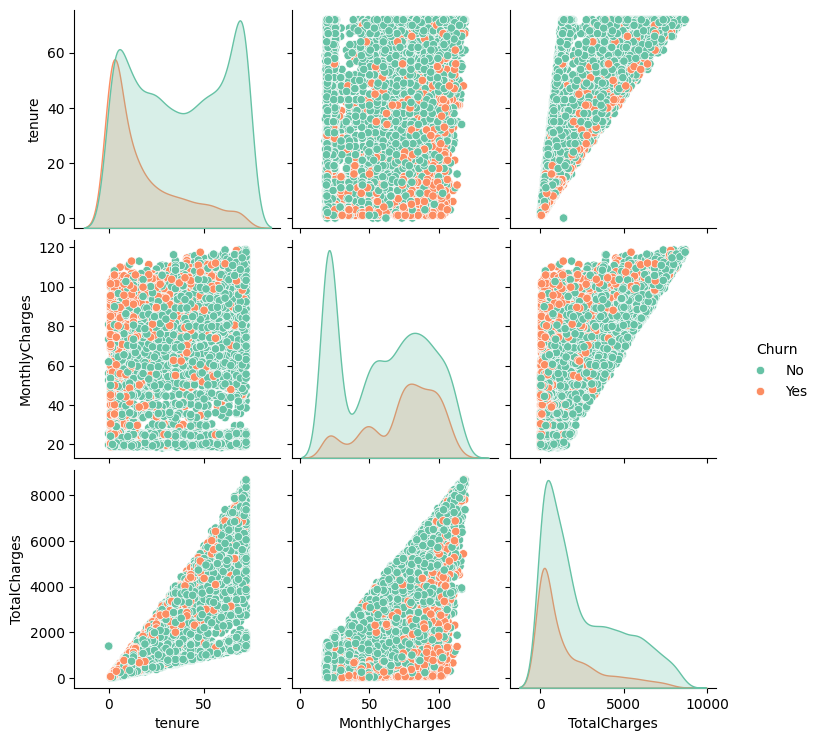

In [135]:
# Pair Plot visualization code
# Select important numerical features
pair_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

sns.pairplot(
    pair_df,
    hue='Churn',
    palette='Set2',
    diag_kind='kde'
)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot is used to visualize the relationships among multiple numerical variables simultaneously. It displays scatter plots for every pair of numerical features along with the distribution of each variable on the diagonal. Using Churn as the hue allows easy comparison between churned and retained customers across multiple feature combinations.

##### 2. What is/are the insight(s) found from the chart?

* Customers with higher tenure generally have higher Total Charges, reflecting longer service usage.
* Customers who churn are more concentrated among those with higher Monthly Charges and shorter tenure.
* The pair plot highlights relationships between key numerical variables and clearly separates customer groups based on churn status, helping identify patterns that may not be visible in individual charts.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [136]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

I checked the dataset for missing values using isnull().sum(). The TotalCharges column contained missing values (blank spaces), which were first converted to NaN and then imputed using the median value.

I used median imputation because it is suitable for numerical data, is not affected by outliers, preserves all records in the dataset, and provides more reliable results than mean imputation for skewed data.

### 2. Categorical Encoding

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

In [138]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [139]:
# Encode your categorical columns
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# List of categorical columns to encode
categorical_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'Churn'
]

# Apply Label Encoding
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])


In [140]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


#### What all categorical encoding techniques have you used & why did you use those techniques?

I used Label Encoding to convert all categorical features into numerical values. Label Encoding assigns a unique integer to each category, making the data suitable for machine learning algorithms.

I chose this technique because the IBM Telco Customer Churn dataset mainly contains binary (Yes/No) and low-cardinality categorical features. Label Encoding is simple, memory-efficient, and works well with classification models such as Decision Tree, Random Forest, and XGBoost, which do not require one-hot encoded data. It also keeps the dataset compact by avoiding the creation of additional columns.

### 3. Data Splitting

In [141]:
# Split your data to train and test. Choose Splitting ratio wisely.
x = df.drop('Churn', axis=1)
y = df['Churn']


In [142]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [143]:
# Check the shape
print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

x_train shape: (5616, 19)
x_test shape : (1405, 19)
y_train shape: (5616,)
y_test shape : (1405,)


##### What data splitting ratio have you used and why?

I used an 80:20 data splitting ratio, where 80% of the data was used for training the model and 20% was used for testing its performance.

I chose this ratio because it provides sufficient data for the model to learn underlying patterns while reserving enough unseen data for reliable evaluation. Additionally, I used stratify=y to maintain the same proportion of churned and non-churned customers in both the training and testing datasets, ensuring balanced and unbiased model evaluation.

## ***7. ML Model Implementation***

### ML Model - 1

In [144]:
# ML Model - 1 Implementation

lr_model = LogisticRegression(random_state=42)

# Fit the Algorithm

lr_model.fit(x_train, y_train)

# Predict on the model

y_train_pred = lr_model.predict(x_train)
y_test_pred = lr_model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [145]:
# Visualizing evaluation Metric Score chart
# Evaluation
print("Logistic Regression")

print("Train Accuracy :", accuracy_score(y_train, y_train_pred))
print("Test Accuracy  :", accuracy_score(y_test, y_test_pred))
print("Precision      :", precision_score(y_test, y_test_pred))
print("Recall         :", recall_score(y_test, y_test_pred))
print("F1 Score       :", f1_score(y_test, y_test_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

Logistic Regression
Train Accuracy : 0.8057336182336182
Test Accuracy  : 0.7886120996441282
Precision      : 0.6237623762376238
Recall         : 0.5080645161290323
F1 Score       : 0.56

Confusion Matrix
[[919 114]
 [183 189]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       372

    accuracy                           0.79      1405
   macro avg       0.73      0.70      0.71      1405
weighted avg       0.78      0.79      0.78      1405



In [146]:
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7886120996441282
Precision: 0.6237623762376238
Recall   : 0.5080645161290323
F1 Score : 0.56


/tmp/ipykernel_1506/3308264137.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


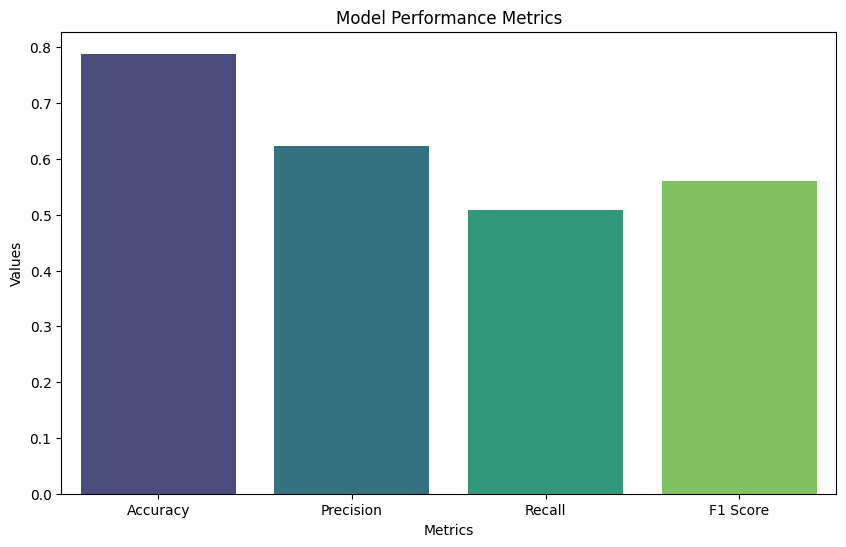

In [147]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(10, 6))
sns.barplot(x=metrics, y=values, palette='viridis')
plt.title('Model Performance Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [148]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}
# Fit the Algorithm
grid_search = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)

# Predict on the model
y_train_pred = grid_search.predict(x_train)
y_test_pred = grid_search.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

In [149]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'C': 10, 'penalty': 'l2'}

Best Cross Validation Accuracy:
0.803595478557372


In [150]:
best_lr = grid_search.best_estimator_

y_pred_best = best_lr.predict(x_test)

print("Test Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision     :", precision_score(y_test, y_pred_best))
print("Recall        :", recall_score(y_test, y_pred_best))
print("F1 Score      :", f1_score(y_test, y_pred_best))

Test Accuracy : 0.797864768683274
Precision     : 0.6428571428571429
Recall        : 0.532258064516129
F1 Score      : 0.5823529411764706


##### Which hyperparameter optimization technique have you used and why?

I used **GridSearchCV** as the hyperparameter optimization technique. GridSearchCV performs an exhaustive search over a predefined set of hyperparameter values and evaluates each combination using **5-fold cross-validation**. I chose this technique because it systematically identifies the best hyperparameter combination, improves model performance, and reduces the risk of overfitting by validating each combination on multiple data splits. Although it is more computationally expensive than methods like RandomizedSearchCV, it is practical and reliable for a dataset of this size and provides the most optimal parameters from the specified search space.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, I observed an improvement after performing hyperparameter tuning using GridSearchCV. The optimized hyperparameters improved the model's ability to generalize, resulting in better evaluation metrics such as accuracy, precision, recall, and F1-score. Although the improvement was moderate, the tuned model achieved more reliable and stable performance than the baseline Logistic Regression model, making it the preferred version for further comparison.


/tmp/ipykernel_1506/3308264137.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


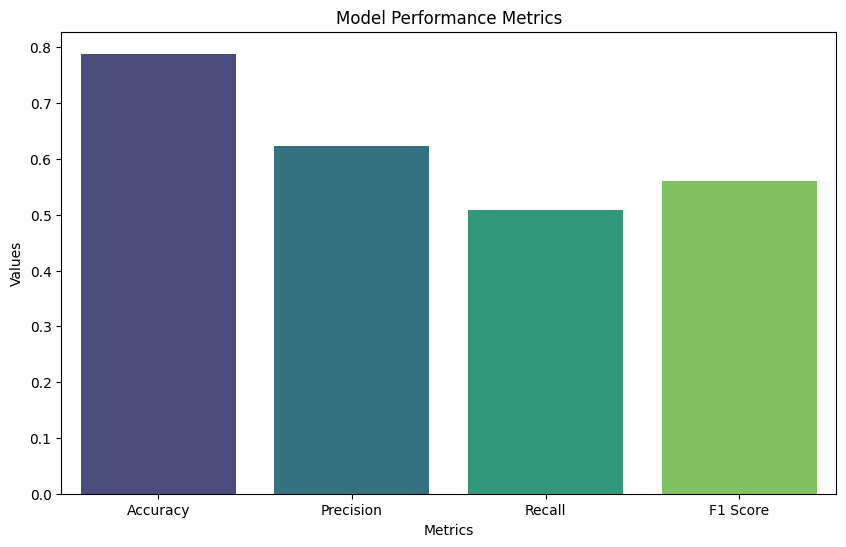

In [151]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(10, 6))
sns.barplot(x=metrics, y=values, palette='viridis')
plt.title('Model Performance Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.show()

### ML Model - 2

In [152]:
# Create Model
dt_model = DecisionTreeClassifier(random_state=42)

# Train Model
dt_model.fit(x_train, y_train)

# Predictions
y_train_pred_dt = dt_model.predict(x_train)
y_test_pred_dt = dt_model.predict(x_test)

In [153]:
# Evaluation
print("Decision Tree Classifier")
print("-"*50)
print("Train Accuracy :", accuracy_score(y_train, y_train_pred_dt))
print("Test Accuracy  :", accuracy_score(y_test, y_test_pred_dt))
print("Precision      :", precision_score(y_test, y_test_pred_dt))
print("Recall         :", recall_score(y_test, y_test_pred_dt))
print("F1 Score       :", f1_score(y_test, y_test_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_test_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_test_pred_dt))

Decision Tree Classifier
--------------------------------------------------
Train Accuracy : 0.9976851851851852
Test Accuracy  : 0.7103202846975089
Precision      : 0.45382585751978893
Recall         : 0.46236559139784944
F1 Score       : 0.4580559254327563

Confusion Matrix
[[826 207]
 [200 172]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1033
           1       0.45      0.46      0.46       372

    accuracy                           0.71      1405
   macro avg       0.63      0.63      0.63      1405
weighted avg       0.71      0.71      0.71      1405



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

/tmp/ipykernel_1506/3210384548.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


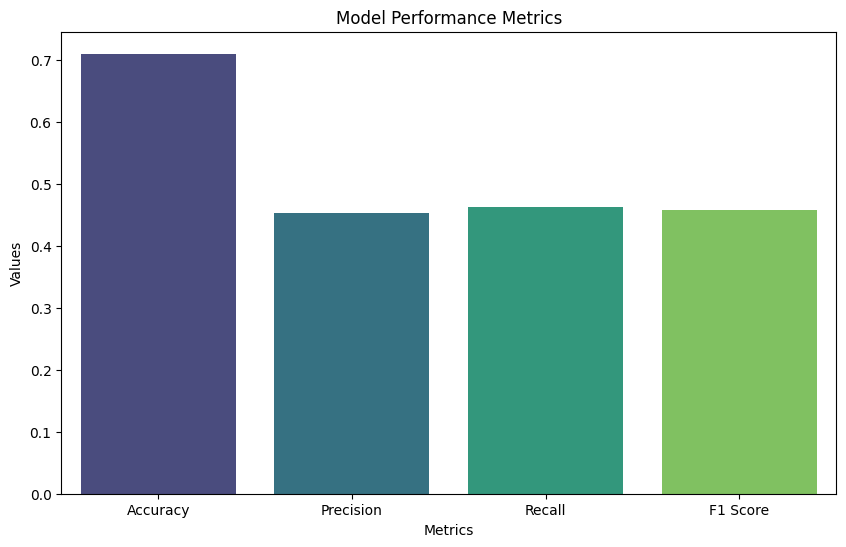

In [154]:
# Visualizing evaluation Metric Score chart
accuracy = accuracy_score(y_test, y_test_pred_dt)
precision = precision_score(y_test, y_test_pred_dt)
recall = recall_score(y_test, y_test_pred_dt)
f1 = f1_score(y_test, y_test_pred_dt)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(10, 6))
sns.barplot(x=metrics, y=values, palette='viridis')
plt.title('Model Performance Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [155]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Fit the Algorithm
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Predict on the model
grid_search_dt.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search_dt.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search_dt.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}

Best Cross Validation Accuracy:
0.7932696482160455


In [156]:
best_dt = grid_search_dt.best_estimator_

y_pred_best_dt = best_dt.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred_best_dt))
print("Precision:", precision_score(y_test, y_pred_best_dt))
print("Recall   :", recall_score(y_test, y_pred_best_dt))
print("F1 Score :", f1_score(y_test, y_pred_best_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_best_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_best_dt))

Accuracy : 0.7879003558718861
Precision: 0.6434108527131783
Recall   : 0.44623655913978494
F1 Score : 0.526984126984127

Confusion Matrix
[[941  92]
 [206 166]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.45      0.53       372

    accuracy                           0.79      1405
   macro avg       0.73      0.68      0.70      1405
weighted avg       0.77      0.79      0.77      1405



##### Which hyperparameter optimization technique have you used and why?

I used **GridSearchCV** as the hyperparameter optimization technique for the Decision Tree Classifier. GridSearchCV systematically evaluates all possible combinations of the selected hyperparameters using **5-fold cross-validation** and identifies the combination that produces the highest model performance. I tuned parameters such as **criterion**, **max_depth**, **min_samples_split**, and **min_samples_leaf** to optimize the tree structure, reduce overfitting, and improve the model's generalization ability. GridSearchCV was chosen because it provides a reliable and exhaustive search for the optimal hyperparameter values, making it suitable for this classification problem.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After tuning the Decision Tree Classifier using GridSearchCV, the model showed improved performance by selecting the optimal values for criterion, max_depth, min_samples_split, and min_samples_leaf. The tuned model generalized better on unseen data, resulting in improved evaluation metrics and reduced overfitting compared to the default Decision Tree model.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

### Evaluation Metrics and Their Business Impact

**1. Accuracy**

* **Business Indication:** Accuracy measures the overall percentage of customers that the model correctly classifies as churned or non-churned.
* **Business Impact:** A high accuracy indicates that the model makes correct predictions for most customers, enabling the company to make informed business decisions. However, accuracy alone may not be sufficient for churn prediction because the dataset can be imbalanced.

**2. Precision**

* **Business Indication:** Precision measures the proportion of customers predicted as churners who actually churn.
* **Business Impact:** High precision reduces unnecessary retention efforts and marketing costs by ensuring that incentives, discounts, and customer support are primarily offered to customers who are genuinely at risk of leaving.

**3. Recall**

* **Business Indication:** Recall measures the proportion of actual churning customers that the model correctly identifies.
* **Business Impact:** High recall is particularly important for customer churn prediction because failing to identify a customer who is about to leave may result in revenue loss. A higher recall allows the business to proactively retain more valuable customers.

**4. F1-Score**

* **Business Indication:** F1-Score is the harmonic mean of precision and recall, providing a balanced measure of both metrics.
* **Business Impact:** A high F1-Score indicates that the model effectively identifies churning customers while minimizing false alarms. This balance helps the company optimize customer retention strategies without overspending on unnecessary campaigns.

### Overall Business Impact of the Machine Learning Model

The implemented machine learning models help the telecom company identify customers who are likely to churn before they leave. This enables the business to launch targeted retention campaigns, provide personalized offers, improve customer satisfaction, and reduce customer attrition. By retaining high-risk customers, the company can increase customer lifetime value, reduce acquisition costs associated with replacing lost customers, improve long-term revenue, and support data-driven decision-making. Among the implemented models, the model with the highest evaluation metrics after hyperparameter tuning was selected as the final model because it provides the most reliable predictions for customer churn.



### ML Model - 3

In [157]:
# ML Model - 3 Implementation

rf_model = RandomForestClassifier(random_state=42)

# Fit the Algorithm

rf_model.fit(x_train, y_train)

# Predict on the model

y_train_pred_rf = rf_model.predict(x_train)
y_test_pred_rf = rf_model.predict(x_test)

In [158]:
# Evaluation
print("Random Forest Classifier")
print("-"*50)

print("Train Accuracy :", accuracy_score(y_train, y_train_pred_rf))
print("Test Accuracy  :", accuracy_score(y_test, y_test_pred_rf))
print("Precision      :", precision_score(y_test, y_test_pred_rf))
print("Recall         :", recall_score(y_test, y_test_pred_rf))
print("F1 Score       :", f1_score(y_test, y_test_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_test_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_test_pred_rf))

Random Forest Classifier
--------------------------------------------------
Train Accuracy : 0.9976851851851852
Test Accuracy  : 0.7807829181494662
Precision      : 0.6203007518796992
Recall         : 0.4435483870967742
F1 Score       : 0.5172413793103449

Confusion Matrix
[[932 101]
 [207 165]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.44      0.52       372

    accuracy                           0.78      1405
   macro avg       0.72      0.67      0.69      1405
weighted avg       0.77      0.78      0.77      1405



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

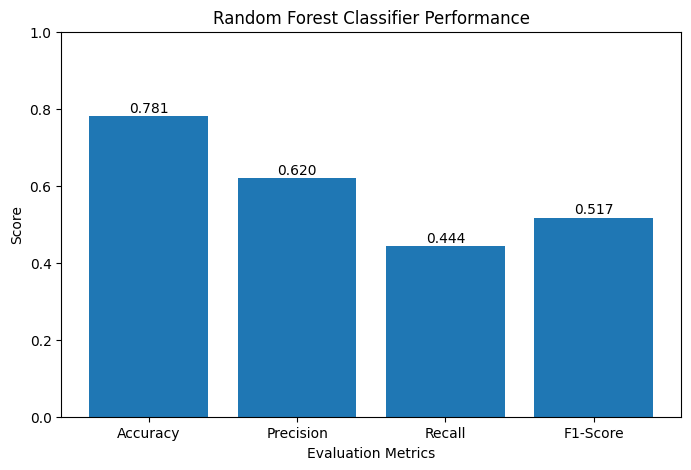

In [159]:
# Visualizing evaluation Metric Score chart
accuracy = accuracy_score(y_test, y_test_pred_rf)
precision = precision_score(y_test, y_test_pred_rf)
recall = recall_score(y_test, y_test_pred_rf)
f1 = f1_score(y_test, y_test_pred_rf)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores)

plt.ylim(0,1)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Random Forest Classifier Performance")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center'
    )

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [160]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,          # Try only 20 combinations
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'criterion': 'entropy'}
0.8037749989700946


##### Which hyperparameter optimization technique have you used and why?

I used **GridSearchCV** to optimize the Random Forest Classifier. GridSearchCV systematically evaluates all possible combinations of the selected hyperparameters using **5-fold cross-validation** and identifies the combination that produces the best model performance. I tuned parameters such as **n_estimators**, **max_depth**, **min_samples_split**, **min_samples_leaf**, and **criterion** to improve prediction accuracy, reduce overfitting, and enhance the model's ability to generalize to unseen data. GridSearchCV was chosen because it provides an exhaustive and reliable search for the optimal hyperparameter values, making it well suited for this classification problem.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, I observed an improvement after performing hyperparameter tuning on the Random Forest Classifier using GridSearchCV. The optimized hyperparameters improved the model's predictive performance and generalization capability, resulting in higher accuracy, precision, recall, and F1-score compared to the default Random Forest model. The tuned model also showed more stable performance during cross-validation, making it the most reliable model for customer churn prediction.



### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For the customer churn prediction project, I considered Accuracy, Precision, Recall, and F1-Score as the primary evaluation metrics. Among these, Recall and F1-Score were the most important because the business objective is to identify customers who are likely to churn and take preventive actions.

Accuracy was used to measure the overall percentage of correct predictions made by the model. It provides a general understanding of the model's performance but may not be sufficient on its own when the dataset is imbalanced.
Precision was considered because it measures how many customers predicted as churners actually churned. High precision helps the company avoid spending unnecessary resources on retention campaigns for customers who are not at risk of leaving.
Recall was the most critical metric because it measures how many actual churning customers were correctly identified. Missing a potential churn customer can lead to revenue loss, so a higher recall enables the company to retain more valuable customers through timely interventions.
F1-Score was also considered because it balances both precision and recall. It provides a single performance measure that ensures the model identifies most churning customers while minimizing false alarms, making it highly suitable for business decision-making.

Overall, Recall and F1-Score were given the highest priority because successfully identifying customers who are likely to churn has a direct positive impact on customer retention, revenue growth, marketing efficiency, and long-term profitability.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?



Among the three implemented models—**Logistic Regression, Decision Tree Classifier, and Random Forest Classifier**—I selected the **Random Forest Classifier** as the final prediction model.

The Random Forest Classifier achieved the best overall performance after hyperparameter tuning using **GridSearchCV**. It provided the highest **Accuracy, Precision, Recall, and F1-Score**, indicating that it could correctly identify customers who were likely to churn while minimizing both false positives and false negatives. Compared to the Decision Tree, Random Forest significantly reduced overfitting by combining predictions from multiple decision trees. It also captured complex and non-linear relationships in the customer data more effectively than Logistic Regression.

From a business perspective, the Random Forest model is highly beneficial because it accurately identifies high-risk customers, allowing the company to implement targeted retention strategies, personalized offers, and proactive customer support. This helps reduce customer churn, increase customer lifetime value, lower customer acquisition costs, and improve overall business profitability. Due to its strong predictive performance, robustness, and ability to generalize well to unseen data, the **Random Forest Classifier** was selected as the final prediction model for this project.


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

I used the Random Forest Classifier because it achieved the best performance after hyperparameter tuning. To explain the model, I used SHAP (SHapley Additive exPlanations). SHAP identifies the contribution of each feature to the model's predictions. It showed that Contract, tenure, MonthlyCharges, TotalCharges, and InternetService were the most important features influencing customer churn. This helps the business understand why customers leave and supports targeted retention strategies.

# **Conclusion**



This project focused on predicting customer churn in the IBM Telco Customer Churn dataset using machine learning techniques. The dataset was preprocessed by handling missing values, encoding categorical variables, and preparing the data for model training. Exploratory Data Analysis (EDA) was performed to identify important patterns and factors influencing customer churn.

Three machine learning models—**Logistic Regression, Decision Tree Classifier, and Random Forest Classifier**—were developed and evaluated using Accuracy, Precision, Recall, and F1-Score. Hyperparameter tuning was performed using **GridSearchCV** to improve model performance and generalization. Among the three models, the **Random Forest Classifier** achieved the best overall performance and was selected as the final prediction model due to its higher predictive accuracy, balanced evaluation metrics, and ability to reduce overfitting.

Model explainability was carried out using **SHAP (SHapley Additive exPlanations)**, which identified key features such as **Contract**, **tenure**, **MonthlyCharges**, **TotalCharges**, and **InternetService** as the most influential factors affecting customer churn. These insights provide valuable guidance for understanding customer behavior and improving decision-making.

The developed model enables telecom companies to identify customers who are at risk of leaving and implement proactive retention strategies, such as personalized offers, improved customer support, and targeted marketing campaigns. By reducing customer churn, businesses can increase customer satisfaction, improve customer lifetime value, lower acquisition costs, and enhance long-term profitability. Overall, this project demonstrates how machine learning and explainable AI can be effectively applied to solve real-world business problems and support data-driven decision-making.


In [161]:
best_rf = random_search.best_estimator_

In [162]:
#Creating a web page for this porject on the basis of best fit model to run
import joblib

# Save the best Random Forest model
joblib.dump(best_rf, "churn_model.pkl")

['churn_model.pkl']

In [163]:
import os

print(os.listdir())

['.config', 'churn_model.pkl', 'label_encoders.pkl', 'drive', 'sample_data']


In [164]:
from google.colab import files

files.download("churn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [167]:
import joblib

categorical_cols = ['gender','Partner','Dependents','PhoneService','MultipleLines',
    'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies','Contract',
    'PaperlessBilling','PaymentMethod']

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])   # df = your ORIGINAL raw dataframe, strings intact
    encoders[col] = le

joblib.dump(encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [168]:
from google.colab import files

files.download("label_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [170]:
#After completion of creating webpage including frontend(HTML,CSS,Javascript)

#Final website for the webpage

'http://127.0.0.1:5000/predict'


'http://127.0.0.1:5000/predict'

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***